<a href="https://colab.research.google.com/github/Mariam-mostafa3/mnist_classification/blob/main/mnist_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, confusion_matrix

# Load Data

In [ ]:
data =torchvision.datasets.MNIST(root='./data', train=True, transform=transforms, download=True)

In [ ]:
labels=data.targets
images=data.data

In [ ]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Splitting the Data

In [ ]:
x_train_val,x_test,y_train_val,y_test=train_test_split(images,labels,test_size=0.2,random_state=42)

In [ ]:
x_train,x_valid,y_train,y_valid=train_test_split(x_train_val,y_train_val,test_size=0.2,random_state=42)

In [ ]:
x_train.shape

torch.Size([38400, 28, 28])

In [ ]:
x_train=x_train.reshape(-1,1,28,28)
x_valid=x_valid.reshape(-1,1,28,28)
x_test=x_test.reshape(-1,1,28,28)
y_train=y_train.reshape(-1,1)
y_valid=y_valid.reshape(-1,1)
y_test=y_test.reshape(-1,1)

In [ ]:
x_train.shape


torch.Size([38400, 1, 28, 28])

In [ ]:
y_train.shape

torch.Size([38400, 1])

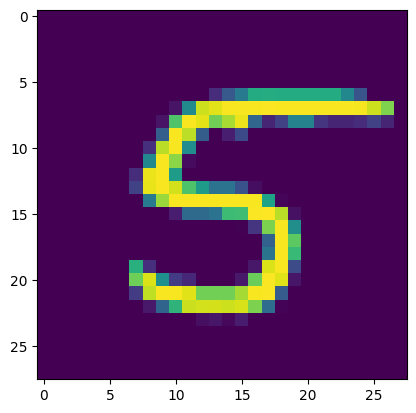

In [ ]:
plt.imshow(x_train[0][0])

In [ ]:

train_dataset = TensorDataset(x_train, y_train)
valid_dataset = TensorDataset(x_valid, y_valid)
test_dataset = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Hyper Parameter

In [ ]:
learning_rate=0.001
num_epochs=5
num_classes=10
batch_size=64

input_size=28*28
hidden_size=500


# Neural Network

In [ ]:
class NeuralNet(nn.Module):
   def __init__(self,input_size,hidden_size,num_classes):
       super(NeuralNet,self).__init__()
       self.l1=nn.Linear(input_size,hidden_size)
       self.relu=nn.ReLU()
       self.l2=nn.Linear(hidden_size,num_classes)
   def forward(self,x):
       out=self.l1(x)
       out=self.relu(out)
       out=self.l2(out)
       return out

In [ ]:
model=NeuralNet(input_size,hidden_size,num_classes)
loss=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)


# Training the model

In [ ]:
n_total_steps = len(train_loader)
train_loss=[]
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        images = images.reshape(-1, 28*28).float().to(device)
        labels = labels.squeeze().to(device)
        outputs = model(images)
        l = loss(outputs, labels)
        train_loss.append(l.item())
        l.backward()
        optimizer.step()
        optimizer.zero_grad()
        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {l.item():.4f}')


Epoch [1/5], Step [100/600], Loss: 0.0456
Epoch [1/5], Step [200/600], Loss: 0.0192
Epoch [1/5], Step [300/600], Loss: 0.0091
Epoch [1/5], Step [400/600], Loss: 0.1625
Epoch [1/5], Step [500/600], Loss: 0.0267
Epoch [1/5], Step [600/600], Loss: 0.0143
Epoch [2/5], Step [100/600], Loss: 0.0073
Epoch [2/5], Step [200/600], Loss: 0.0190
Epoch [2/5], Step [300/600], Loss: 0.0197
Epoch [2/5], Step [400/600], Loss: 0.0035
Epoch [2/5], Step [500/600], Loss: 0.0025
Epoch [2/5], Step [600/600], Loss: 0.0128
Epoch [3/5], Step [100/600], Loss: 0.0070
Epoch [3/5], Step [200/600], Loss: 0.0030
Epoch [3/5], Step [300/600], Loss: 0.0241
Epoch [3/5], Step [400/600], Loss: 0.0192
Epoch [3/5], Step [500/600], Loss: 0.0033
Epoch [3/5], Step [600/600], Loss: 0.0081
Epoch [4/5], Step [100/600], Loss: 0.0102
Epoch [4/5], Step [200/600], Loss: 0.0161
Epoch [4/5], Step [300/600], Loss: 0.0245
Epoch [4/5], Step [400/600], Loss: 0.0097
Epoch [4/5], Step [500/600], Loss: 0.0070
Epoch [4/5], Step [600/600], Loss:

# evaluation

In [ ]:
def evaluate(model, loader, loss):
    model.eval()
    val_losses=[]
    acuracy_val=[]
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.view(-1, 28*28).float().to(device)
            labels = labels.squeeze().to(device)

            outputs = model(images)
            l = loss(outputs, labels)
            total_loss += l.item()
            val_losses.append(l.item())
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            acuracy_val.append(100 * correct / total)

    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy,val_losses,acuracy_val

# Evaluate the validation set

In [ ]:
val_loss, val_acc,val_losses,acuracy_val = evaluate(model, valid_loader, loss)

print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.2f}%")


Validation Loss: 0.1829
Validation Accuracy: 95.94%


# visualization loss & Accuracy

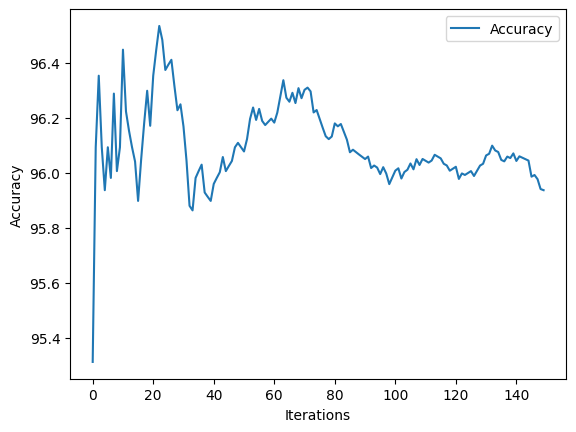

In [ ]:
plt.plot(acuracy_val, label='Accuracy')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

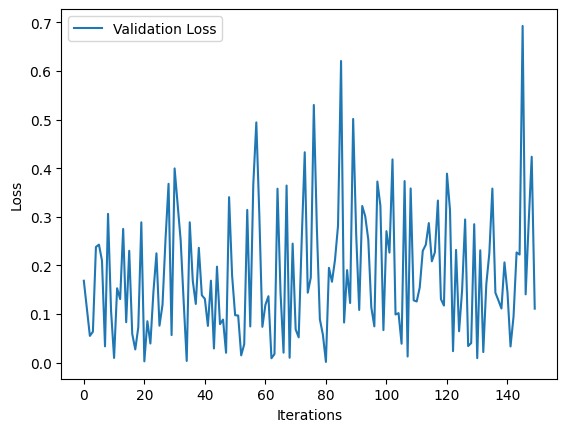

In [ ]:
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluate the Test set

In [ ]:
def evaluate(model, loader, loss):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.view(-1, 28*28).float().to(device)
            labels = labels.squeeze().to(device)

            outputs = model(images)
            l = loss(outputs, labels)
            total_loss += l.item()

            _, predicted = torch.max(outputs.data, 1)


            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    return acc, cm

In [ ]:
test_acc,conf_mat=evaluate(model,test_loader,loss)
print(f"Test Accuracy: {test_acc:.2f}%")
print("Confusion Matrix:")
print(conf_mat)

Test Accuracy: 0.96%
Confusion Matrix:
[[1146    0    4    1    2    4    5    1    8    4]
 [   0 1304    3    5    2    2    2    1    2    1]
 [   3    7 1114    4    7    0    2   11   22    4]
 [   2    7   16 1131    1   22    0    7   20   13]
 [   1    1    6    1 1123    1    5    5    6   27]
 [   9    2    3    5    5 1048    6    3   14    9]
 [  11    1    2    1    3    8 1139    0   12    0]
 [   4   12   14    6    6    0    0 1237    7   13]
 [   5    2    7    8    7   13   12    3 1087   16]
 [   4    2    1    4   14    9    0   18    7 1135]]


# Analysis summary








1.   changing learning rate 0.5,0.01,0.001 and best one 0.001
2.   changing batch size =64  --> accuracy 0.96%
3.   changing batch size =100  --> accuracy 0.95%
4.   changing batch size =50 --> accuracy 0.95%
5.  best batch 64
